# Task 3: Heart Disease Prediction

# Objective:
Build a machine learning model to predict whether a person is at risk of heart disease based on health-related attributes.

## Dataset

Heart Disease UCI Dataset


## Model Used

Decision Tree Classifier

## Import the Libraries

In [47]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

## Load the Dataset

In [48]:
heart=pd.read_csv('heart.csv')

## Exploration of Dataset

In [49]:
print('\nShape: ', heart.shape)
print('\nColumns:\n',heart.columns)
print('\nRows:')
print(heart.head())
print('\nDataset Information:')
print(heart.info())
print('\nSummary Statistics:')
print(heart.describe())


Shape:  (303, 14)

Columns:
 Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    ----

## Missing Values

In [50]:
print('\nMissing Values:')
print(heart.isnull().sum())


Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## Observation:
No missing values were found in the dataset.

## Exploratory Data Analysis (EDA)

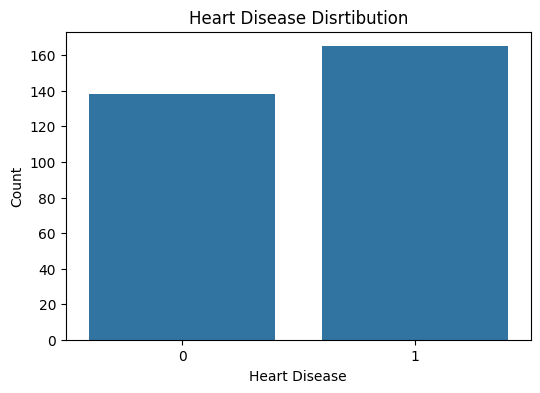

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(data=heart, x='target')
plt.title('Heart Disease Disrtibution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()

## Interpretation
Target = 1 indicates presence of heart disease.

Target = 0 indicates absence of heart disease.

## Coorelation Heatmap

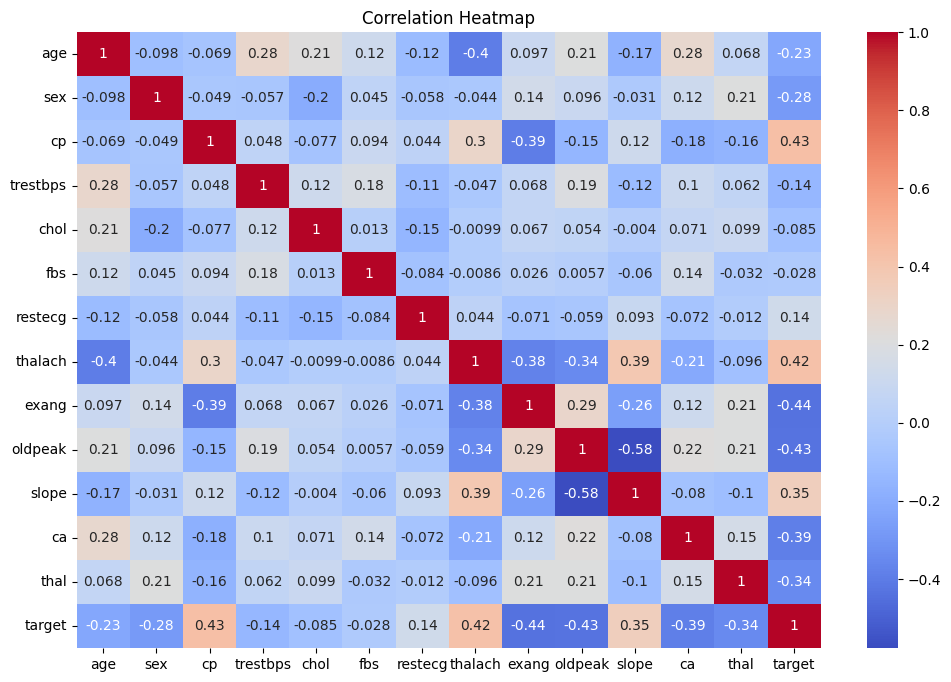

In [52]:
plt.figure(figsize=(12,8))
sns.heatmap(
    heart.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title('Correlation Heatmap')
plt.show()

## Histogram

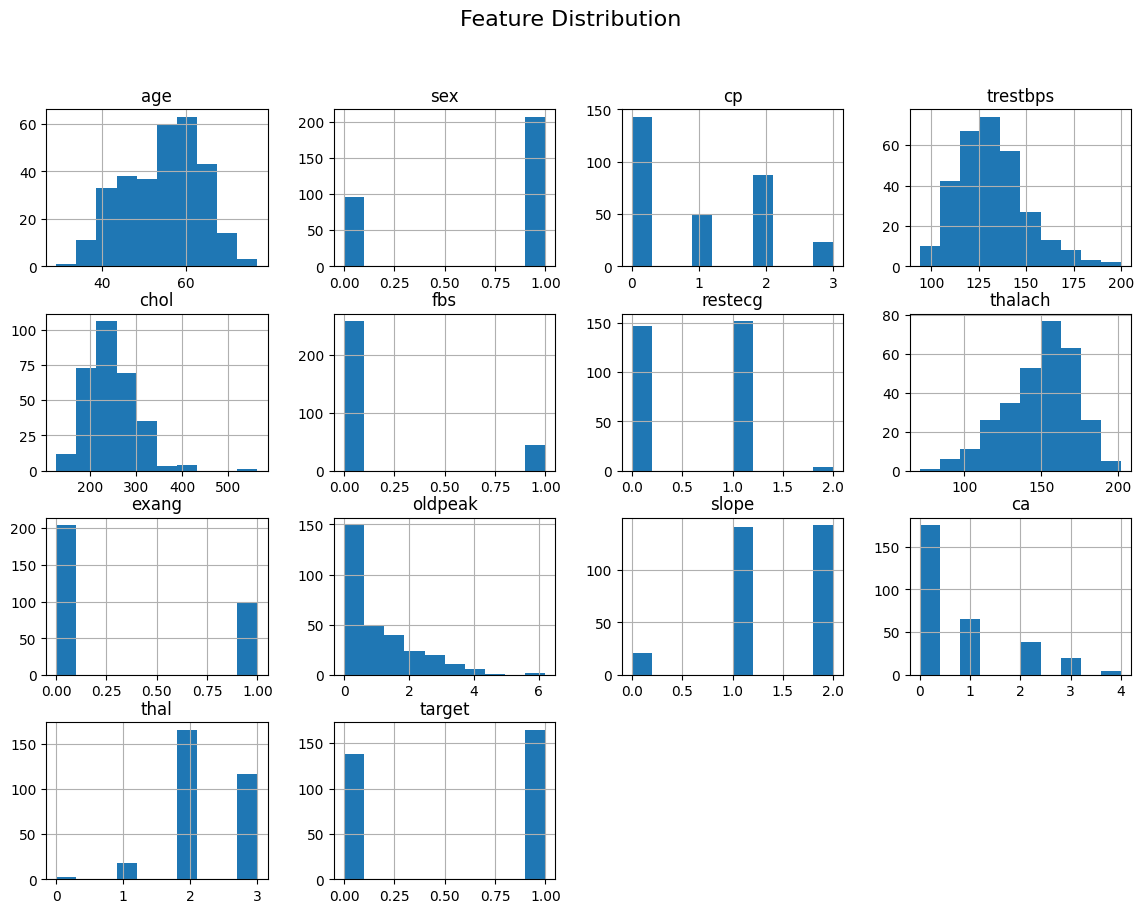

In [53]:
heart.hist(figsize=(14,10))
plt.suptitle('Feature Distribution', fontsize=16)
plt.show()

## Boxplots

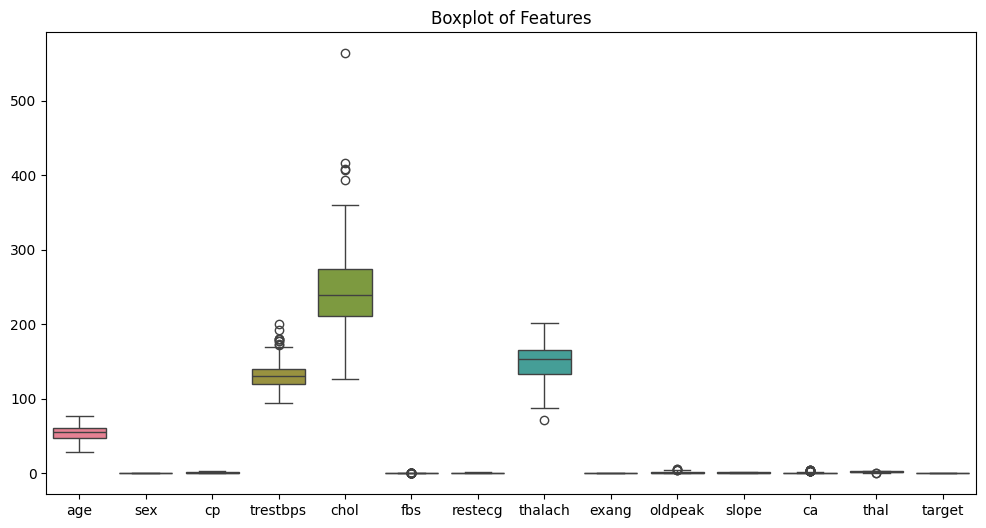

In [54]:
plt.figure(figsize=(12,6))
sns.boxplot(data=heart)
plt.title('Boxplot of Features')
plt.show()

## Prepare Features and Target

In [55]:
x=heart.drop("target", axis=1)
y=heart["target"]

## Train-Test Split

In [56]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

## Train Descision Tree Model

In [57]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

## Predictions

In [58]:
y_pred=model.predict(x_test)

## Accuracy Score


In [59]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score:', accuracy)

Accuracy Score: 0.7540983606557377


## Confusion Matrix

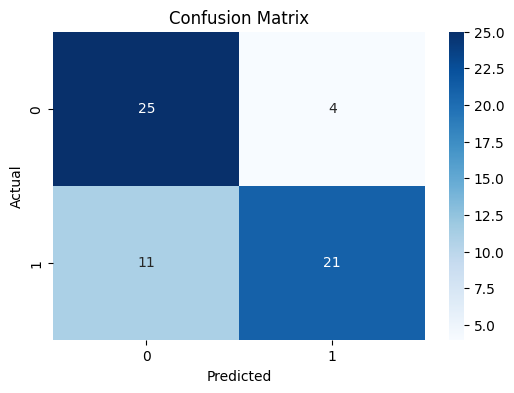

In [60]:
cm= confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.86      0.77        29
           1       0.84      0.66      0.74        32

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61



## ROC Curve

In [62]:
y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.7591594827586207


## Plot ROC Curve

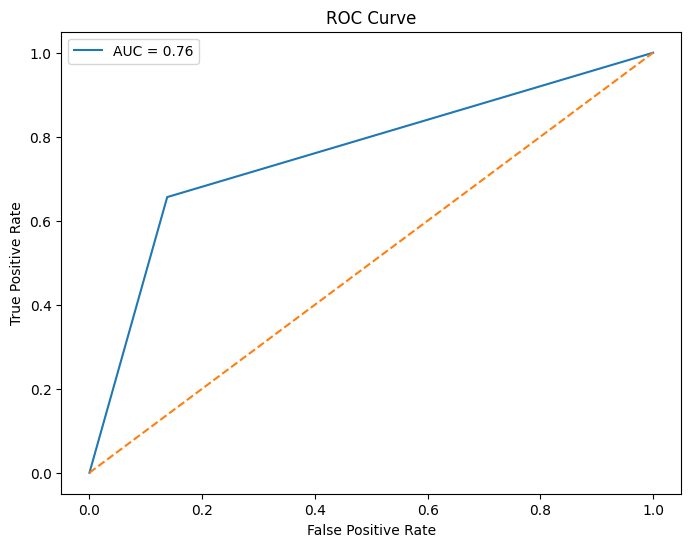

In [63]:
plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    label="AUC = {:.2f}".format(auc)
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Feature Importance

In [64]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

     Feature  Importance
2         cp    0.225263
11        ca    0.118478
9    oldpeak    0.113268
0        age    0.106735
4       chol    0.093679
3   trestbps    0.081394
8      exang    0.075421
7    thalach    0.046207
1        sex    0.041015
10     slope    0.038537
12      thal    0.027214
5        fbs    0.016693
6    restecg    0.016097


## Visualize Feature Importance

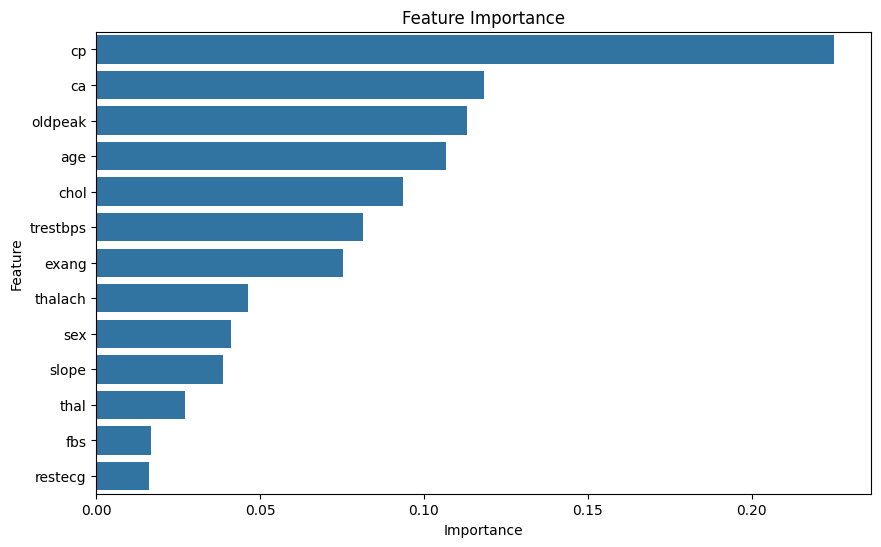

In [65]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()

# Results and Insights

- The Heart Disease dataset contains 303 patient records and 14 attributes.
- No missing values were found in the dataset.
- A Decision Tree Classifier was trained to predict heart disease.
- Model performance was evaluated using Accuracy, Confusion Matrix, and ROC-AUC.
- Feature importance analysis revealed the most influential health indicators.
- The model demonstrated the ability to distinguish between patients with and without heart disease.